Revisión de Dataset unificado y limpio

In [2275]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

df = pd.read_csv("../data/processed/nasa_train_all_fd_clean1.csv")
engines = df["engine_id"].unique()
print("Total motores:", len(engines))
df.head(10)

Total motores: 709


,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,dataset_id
0,FD001_1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,21.61,554.36,2388.06,9046.19,1.3,47.47,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,FD001
1,FD001_1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,21.61,553.75,2388.04,9044.07,1.3,47.49,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,FD001
2,FD001_1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,21.61,554.26,2388.08,9052.94,1.3,47.27,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,FD001
3,FD001_1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,21.61,554.45,2388.11,9049.48,1.3,47.13,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,FD001
4,FD001_1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,21.61,554.00,2388.06,9055.15,1.3,47.28,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,FD001
5,FD001_1,6,-0.0043,-0.0001,100.0,518.67,642.10,1584.47,1398.37,14.62,21.61,554.67,2388.02,9049.68,1.3,47.16,521.68,2388.03,8132.85,8.4108,0.03,391,2388,100.0,38.98,23.3669,FD001
6,FD001_1,7,0.0010,0.0001,100.0,518.67,642.48,1592.32,1397.77,14.62,21.61,554.34,2388.02,9059.13,1.3,47.36,522.32,2388.03,8132.32,8.3974,0.03,392,2388,100.0,39.10,23.3774,FD001
7,FD001_1,8,-0.0034,0.0003,100.0,518.67,642.56,1582.96,1400.97,14.62,21.61,553.85,2388.00,9040.80,1.3,47.24,522.47,2388.03,8131.07,8.4076,0.03,391,2388,100.0,38.97,23.3106,FD001
8,FD001_1,9,0.0008,0.0001,100.0,518.67,642.12,1590.98,1394.80,14.62,21.61,553.69,2388.05,9046.46,1.3,47.29,521.79,2388.05,8125.69,8.3728,0.03,392,2388,100.0,39.05,23.4066,FD001
9,FD001_1,10,-0.0033,0.0001,100.0,518.67,641.71,1591.24,1400.46,14.62,21.61,553.59,2388.05,9051.70,1.3,47.03,521.79,2388.06,8129.38,8.4286,0.03,393,2388,100.0,38.95,23.4694,FD001


In [2276]:
# Tamaño de filas y Columnas
df.shape

(160359, 27)

In [2277]:
# Identidficación de Variables
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 160359 entries, 0 to 160358
Data columns (total 27 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   engine_id     160359 non-null  object 
 1   cycle         160359 non-null  int64  
 2   op_setting_1  160359 non-null  float64
 3   op_setting_2  160359 non-null  float64
 4   op_setting_3  160359 non-null  float64
 5   sensor_1      160359 non-null  float64
 6   sensor_2      160359 non-null  float64
 7   sensor_3      160359 non-null  float64
 8   sensor_4      160359 non-null  float64
 9   sensor_5      160359 non-null  float64
 10  sensor_6      160359 non-null  float64
 11  sensor_7      160359 non-null  float64
 12  sensor_8      160359 non-null  float64
 13  sensor_9      160359 non-null  float64
 14  sensor_10     160359 non-null  float64
 15  sensor_11     160359 non-null  float64
 16  sensor_12     160359 non-null  float64
 17  sensor_13     160359 non-null  float64
 18  sens

Descripción Estadística: 
. Rangos reales
. Se detecta sensores planos
. Se entiende magnitudes

In [2278]:
# Estadístico descriptivos de análisis para detectar escalas distintas y sensores poco informativos.
sensor_cols = [c for c in df.columns if c.startswith("sensor_")]
df[sensor_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
sensor_1,160359.0,485.840890,30.420388,445.0000,449.44000,489.0500,518.6700,518.6700
sensor_2,160359.0,597.361022,42.478516,535.4800,549.96000,605.9300,642.3400,645.1100
sensor_3,160359.0,1467.035653,118.175261,1242.6700,1357.36000,1492.8100,1586.5900,1616.9100
sensor_4,160359.0,1260.956434,136.300073,1023.7700,1126.83000,1271.7400,1402.2000,1441.4900
sensor_5,160359.0,9.894999,4.265554,3.9100,5.48000,9.3500,14.6200,14.6200
sensor_6,160359.0,14.424935,6.443922,5.6700,8.00000,13.6600,21.6100,21.6100
sensor_7,160359.0,359.729968,174.133835,136.1700,175.71000,341.6900,553.2900,570.8100
sensor_8,160359.0,2273.829707,142.426613,1914.7200,2212.12000,2319.3700,2388.0500,2388.6400
sensor_9,160359.0,8677.553696,374.657454,7984.5100,8334.77000,8764.2000,9055.8500,9244.5900
sensor_10,160359.0,1.153705,0.142103,0.9300,1.02000,1.0900,1.3000,1.3200


Normalización: se aplicó una normalización estadística a las variables sensoriales con el fin de facilitar la comparación entre señales de diferentes escalas, mejorar la interpretación de las distribuciones y permitir la aplicación de técnicas como el análisis de componentes principales.

In [2279]:
sensor_cols = [c for c in df.columns if c.startswith("sensor_")] # Selección de sensores 
df_eda = df.copy()

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_eda[sensor_cols] = scaler.fit_transform(df_eda[sensor_cols])

sensor_cols = [c for c in df.columns if c.startswith("sensor_")]

Histogramas Individuales  de sensores
. Observación de la distribución por sensor
.Confirmar que no siguen distribución normal

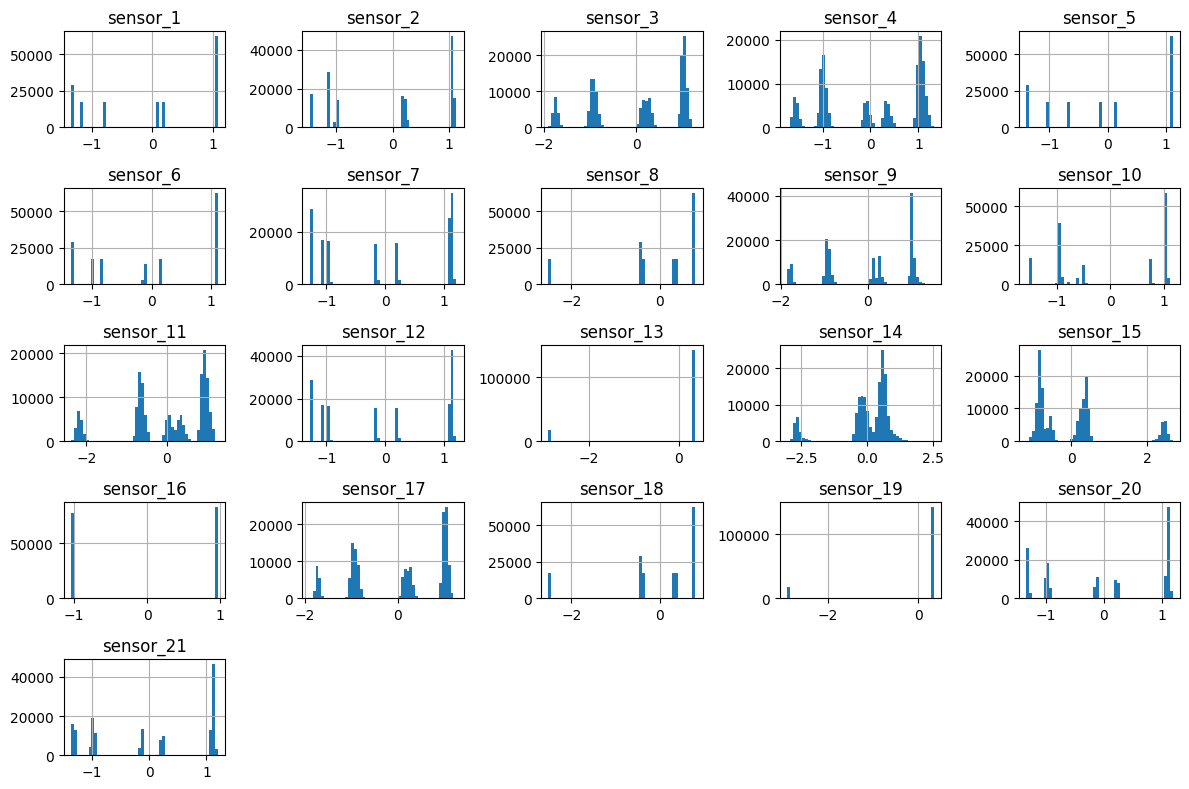

In [2280]:
# Distribución de sensores 
# Sensores no son normales, el comportamiento no es lineal, señales ruidosas, distribuciones multimodales
# Presenta varios picos lo que conlleva a diferentes estados del sistema. Diferentes regímenes de operación
#Diferentes fases de degradación
# Justifica la normalización de sensores ya que estan centrados alrededor de 0
sample_sensors = sensor_cols[:21]

df_eda[sample_sensors].hist(
    figsize=(12, 8),
    bins=50
)
plt.tight_layout()
plt.show()


Matriz de correlación: observo si hay que aplicar reducción dimensional y justifico el uso de PCA para Health Index.
.Detectar correlación entre sensores y confirmar redundancia de información 

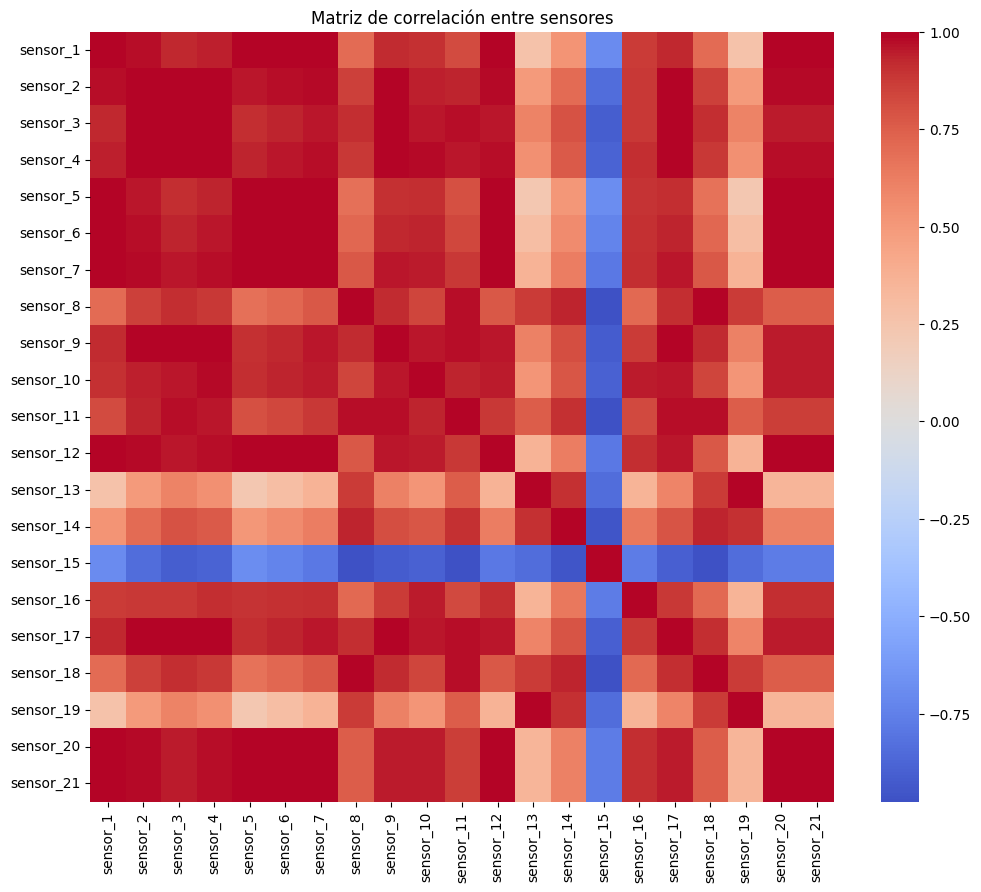

In [2281]:
# Alta correlación positiva ( presenta un rojo intenso)
# Presenta sensores redundantes y miden fenómenos similares
# Implica posible reducción de dimencionalidad, aplicación de PCA (Análisis de componente principal)
# Al contrario el sensor 15 presenta correlación negativa lo cual implica que es crítico y puede ser usado como:
# Indicador temprano a fallo, degradación

corr = df_eda[sensor_cols].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Matriz de correlación entre sensores")
plt.show()

In [2282]:
# Detectar sensores REDUNDANTES ya que existe correlación alta
# Si no se quita los sensores que redundan, aumenta el sobreajuste del modelo, reduciendo detección de anomalías y sesgandolo
corr_matrix = df_eda[sensor_cols].corr().abs()

high_corr = (
    corr_matrix
    .where(corr_matrix > 0.90)
    .stack()
)

high_corr = high_corr[high_corr < 1]


high_corr_df = (
    high_corr
    .reset_index()
    .rename(columns={
        "level_0": "sensor_A",
        "level_1": "sensor_B",
        0: "correlation"
    })
    .sort_values("correlation", ascending=False)
)

high_corr_unique = high_corr_df[
    high_corr_df["sensor_A"] < high_corr_df["sensor_B"]
].reset_index(drop=True)

high_corr_unique.head(20)

,sensor_A,sensor_B,correlation
0,sensor_18,sensor_8,0.999999
1,sensor_13,sensor_19,0.999998
2,sensor_12,sensor_7,0.999995
3,sensor_20,sensor_21,0.999927
4,sensor_20,sensor_7,0.999511
5,sensor_21,sensor_7,0.999511
6,sensor_12,sensor_20,0.999479
7,sensor_12,sensor_21,0.999479
8,sensor_17,sensor_3,0.998944
9,sensor_17,sensor_9,0.998370


In [2283]:
high_corr_unique.to_csv(
    "highly_correlated_sensors.csv",
    index=False
)

In [2284]:
# grado de redundancia por sensor
# sensores que están altamente correlacionados con MUCHOS otros

corr = df_eda[sensor_cols].corr().abs()
redundancy_score = (corr > 0.90).sum(axis=1)
redundancy_score.sort_values(ascending=False)


sensor_3     17
sensor_17    17
sensor_9     17
sensor_4     15
sensor_10    15
sensor_12    14
sensor_20    14
sensor_2     14
sensor_7     14
sensor_21    14
sensor_6     14
sensor_5     13
sensor_1     13
sensor_11    10
sensor_8      8
sensor_18     8
sensor_15     8
sensor_16     8
sensor_14     6
sensor_13     3
sensor_19     3
dtype: int64

In [2285]:
# sensores que cambian con el ciclo a medida que el motor envejece.
# Relación con degradación. 
sensor_cols = [c for c in df.columns if "sensor_" in c]

corr_cycle = (
    df[sensor_cols + ["cycle"]]
    .corr()["cycle"]
    .drop("cycle")
    .abs()
    .sort_values(ascending=False)
)

print(corr_cycle)


sensor_14    0.098462
sensor_11    0.043362
sensor_16    0.043034
sensor_4     0.036380
sensor_9     0.033241
sensor_17    0.029852
sensor_3     0.029766
sensor_10    0.017375
sensor_15    0.017034
sensor_12    0.013595
sensor_7     0.013459
sensor_2     0.012651
sensor_21    0.010593
sensor_20    0.010540
sensor_5     0.010034
sensor_1     0.009526
sensor_6     0.009417
sensor_8     0.005933
sensor_18    0.005334
sensor_13    0.001481
sensor_19    0.000687
Name: cycle, dtype: float64


Series Temporales por motor: Observación de degradación progresiva e identificación de saltos abruptos

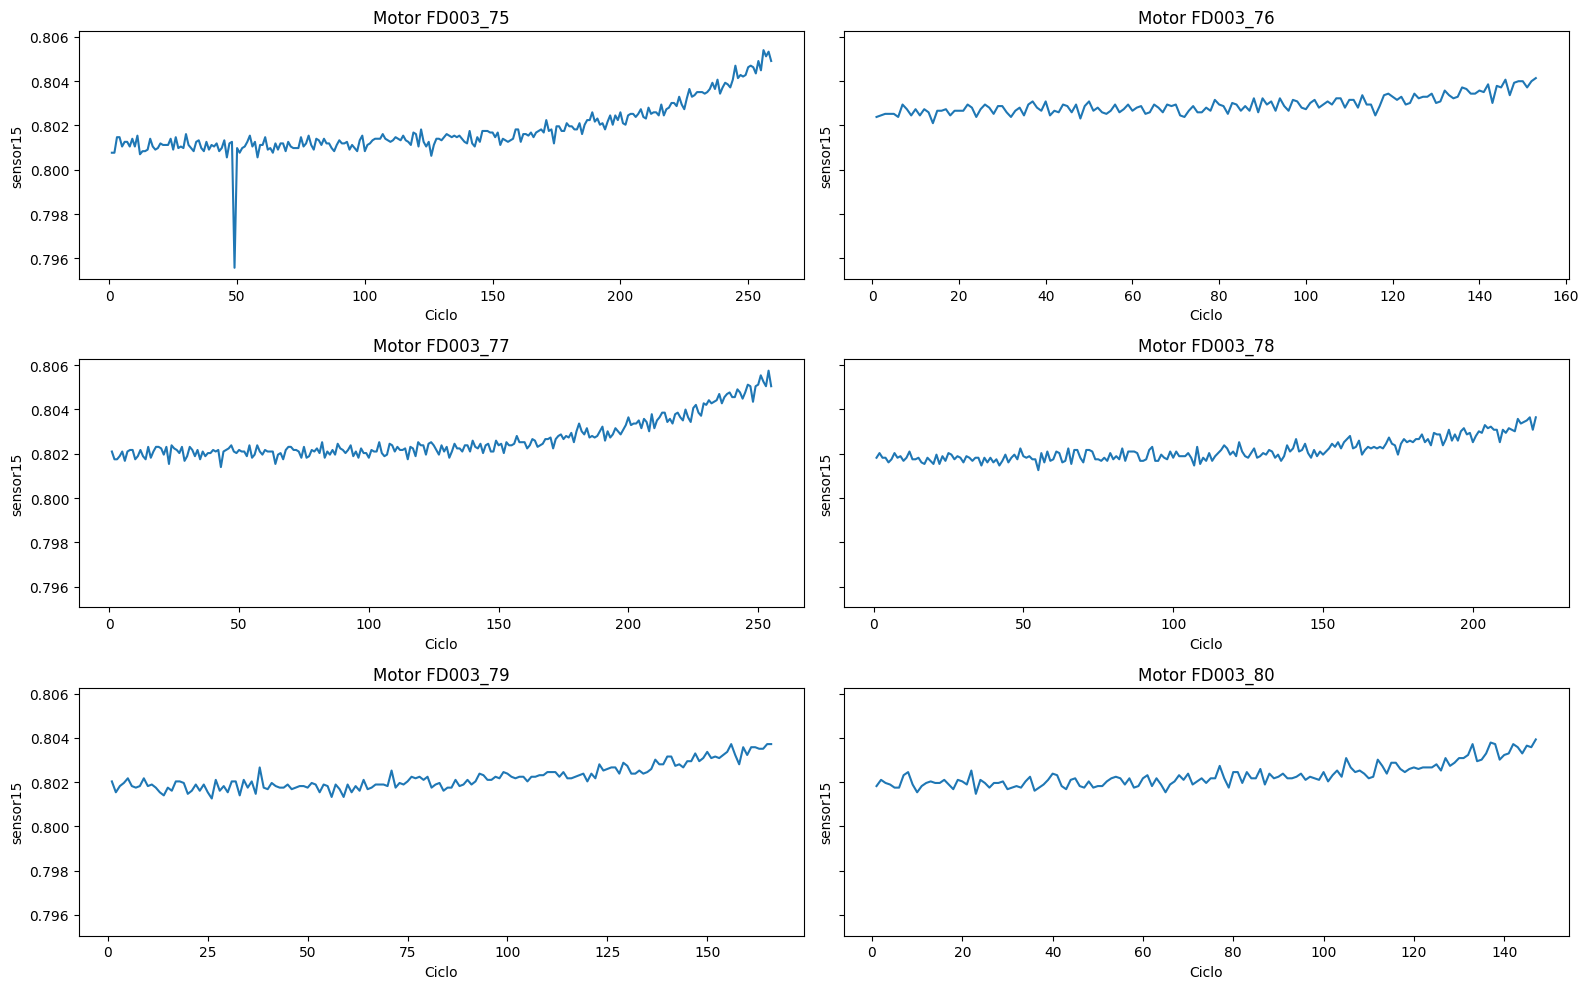

In [2286]:
# Evolución temporal
#degradación progresiva, patrones antes de que falle, justificación para el enfoque predictivo.
df_fd = df_eda[df_eda["dataset_id"] == "FD003"]
engine_ids = df_fd["engine_id"].unique()[74:80]
fig, axes = plt.subplots(3, 2, figsize=(16, 10), sharey=True)
axes = axes.flatten()
for ax, engine_id in zip(axes, engine_ids):
    df_engine = df_fd[df_fd["engine_id"] == engine_id]
    ax.plot(df_engine["cycle"], df_engine["sensor_8"])
    ax.set_title(f"Motor {engine_id}")
    ax.set_xlabel("Ciclo")
    ax.set_ylabel("sensor15")

plt.tight_layout()
plt.show()


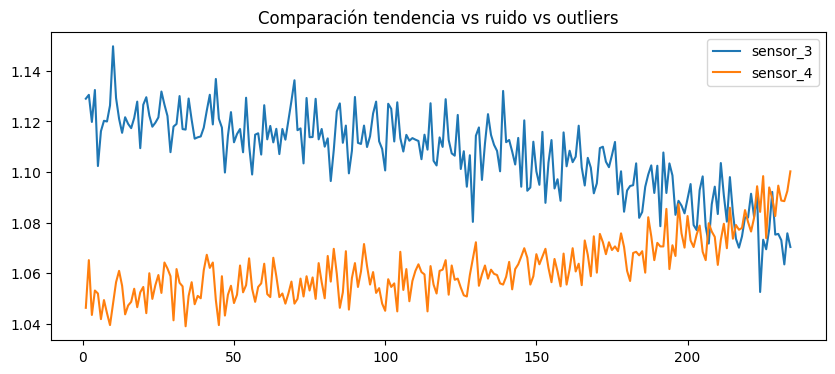

In [2287]:
import matplotlib.pyplot as plt

motor = "FD003_65"

df_motor = df_eda[df_eda["engine_id"] == motor]

plt.figure(figsize=(10,4))
plt.plot(df_motor["cycle"], df_motor["sensor_21"], label="sensor_3")
plt.plot(df_motor["cycle"], df_motor["sensor_2"], label="sensor_4")
plt.legend()
plt.title("Comparación tendencia vs ruido vs outliers")
plt.show()


<Figure size 1000x400 with 0 Axes>

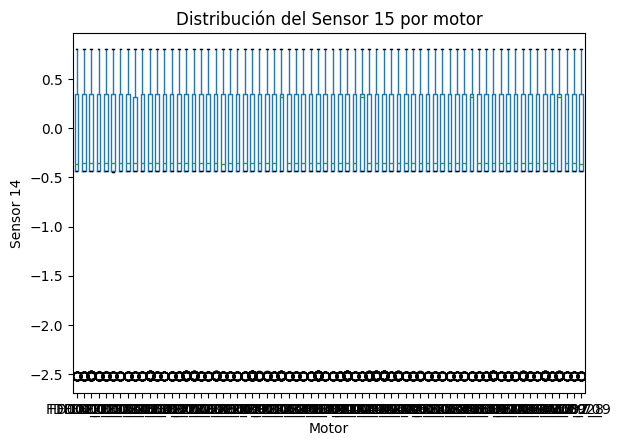

In [2288]:
# Grafico de diagrama de caja
# Diferencia en medianas
# Outliers (Puntos negros) y distinatas disperciones
# El sensor 9 no se compara igual en todos los motores
# Presenta valores extremos aislados, que pueden ser candidatos a anomalía
# Motores que muestran mayor variabilidad indican:
# Condiciones anómalas y sensibilidad al desgaste
df_fd1 = df_eda[df_eda["dataset_id"] == "FD002"]
selected_engines = df_fd1["engine_id"].unique()[:70]
df_sel = df_eda[df_eda["engine_id"].isin(selected_engines)]
plt.figure(figsize=(10,4))
df_sel.boxplot(
    column="sensor_8",
    by="engine_id",
    grid=False
)

plt.xlabel("Motor")
plt.ylabel("Sensor 14")
plt.title("Distribución del Sensor 15 por motor")
plt.suptitle("")
plt.show()


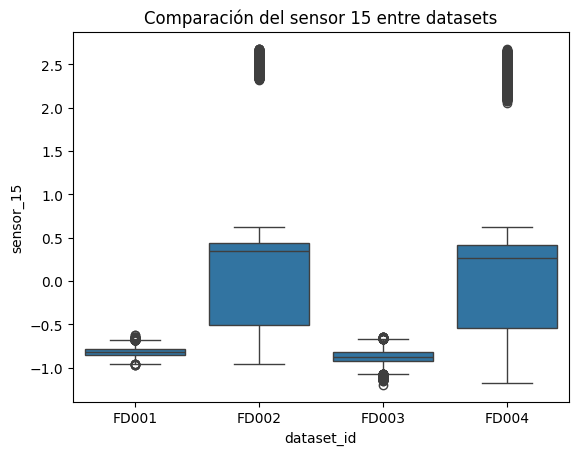

In [2289]:
# Comparación entre datasets (FD001–FD004)
#Diferentes condiciones operativas, hay distintos modos de falla, razón por la cual no se normaliza globalmente para ML sino por motor.
sns.boxplot(
    data=df_eda,
    x="dataset_id",
    y="sensor_15"
)
plt.title("Comparación del sensor 15 entre datasets")
plt.show()

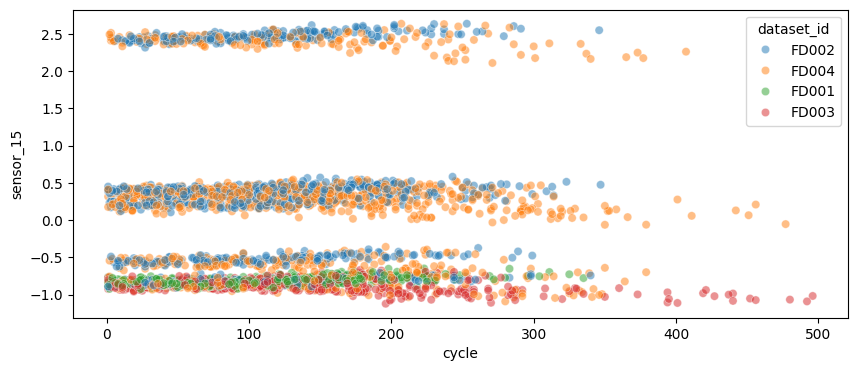

In [2290]:
# Detección visual de anomalías
# el enfoque es hacia la detección de anomalías 
# mantenimiento predictivo
# Regímenes discretos (multimodalidad), aclara el uso de PCA para mejor análisis.
# Dependencia con el ciclo
plt.figure(figsize=(10, 4))
sns.scatterplot(
    data=df_eda.sample(3000),
    x="cycle",
    y="sensor_15",
    hue="dataset_id",
    alpha=0.5
)
plt.show()


# Series temporales por motor usando:
Health Index (HI): Presenta un estado latente de salud
- Combinar todos los sensores
- Capturaar el patron dominante de degradación
- resume comportamiento multivariado
El Health Index se construyó con PCA, y el PCA asigna pesos (loadings) a cada sensor.

In [2291]:
# Selección de sensores 
sensor_cols = [c for c in df.columns if c.startswith("sensor_")]
df_eda = df.copy()
# Normalización 
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df_eda[sensor_cols] = scaler.fit_transform(df_eda[sensor_cols])

# Aplicación de PCA (Análisis de componente principal) para Health Index
from sklearn.decomposition import PCA

pca = PCA(n_components=1) # Extrae la primera componente
df_eda["health_index"] = pca.fit_transform(df_eda[sensor_cols])


PCA construye una combinación lineal de TODOS los sensores:
- PC1 (Health Index)= w1​⋅sensor1​ + w2​⋅sensor2​+...+wn​⋅sensorn​
- 𝑤𝑖 son las cargas (loadings)
- Se analiza  qué sensor contribuye más

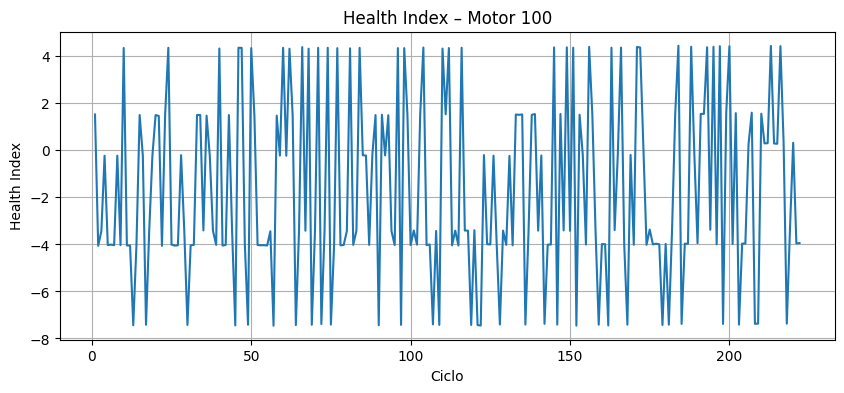

In [2292]:
engine_1 = df_eda[df_eda["engine_id"] == "FD002_50"]

plt.figure(figsize=(10,4))
plt.plot(engine_1["cycle"], engine_1["health_index"])
plt.xlabel("Ciclo")
plt.ylabel("Health Index")
plt.title("Health Index – Motor 100")
plt.grid(True)
plt.show()


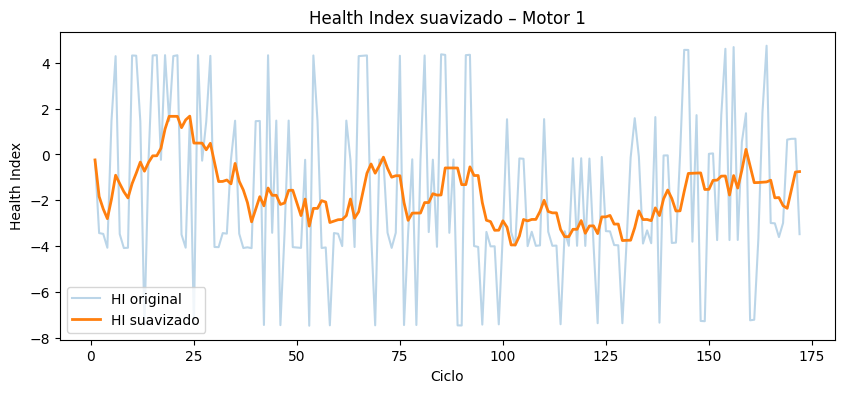

In [2293]:
# Suavizado del HI
engine_1 = df_eda[df_eda["engine_id"] == "FD004_50"].copy()

engine_1["hi_smooth"] = (
    engine_1["health_index"]
    .rolling(window=10, min_periods=1)
    .mean()
)

plt.figure(figsize=(10,4))
plt.plot(engine_1["cycle"], engine_1["health_index"], alpha=0.3, label="HI original")
plt.plot(engine_1["cycle"], engine_1["hi_smooth"], linewidth=2, label="HI suavizado")
plt.xlabel("Ciclo")
plt.ylabel("Health Index")
plt.title("Health Index suavizado – Motor 1")
plt.legend()
plt.show()


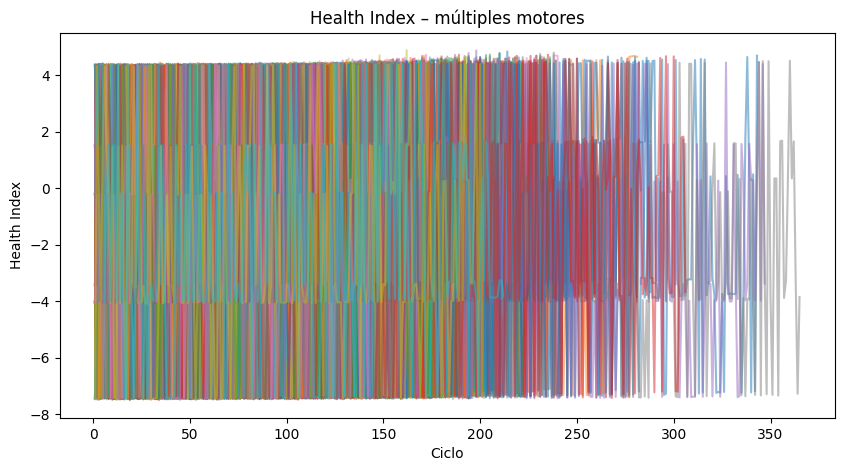

In [2294]:
plt.figure(figsize=(10,5))
df_fd1 = df_eda[df_eda["dataset_id"] == "FD002"]
for eid in df_fd1["engine_id"].unique()[:100]:
    e = df_fd1[df_fd1["engine_id"] == eid]
    plt.plot(e["cycle"], e["health_index"], alpha=0.5)

plt.xlabel("Ciclo")
plt.ylabel("Health Index")
plt.title("Health Index – múltiples motores")
plt.show()


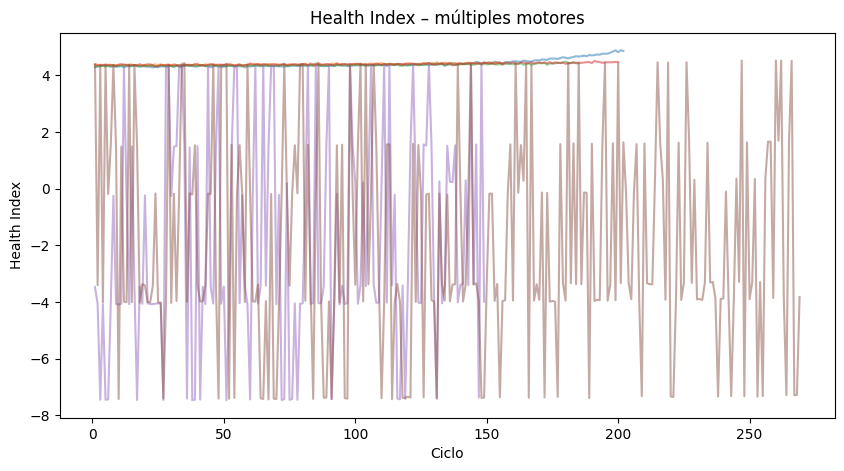

In [2295]:
plt.figure(figsize=(10,5))
for eid in df_eda["engine_id"].unique()[96:102]:
    e = df_eda[df_eda["engine_id"] == eid]
    plt.plot(e["cycle"], e["health_index"], alpha=0.5)

plt.xlabel("Ciclo")
plt.ylabel("Health Index")
plt.title("Health Index – múltiples motores")
plt.show()


In [2296]:

engine_1 = df_eda[df_eda["engine_id"] == "FD004_249"]

engine_1[["cycle", "health_index"]].head()
engine_1[["cycle", "health_index"]].tail(10)


,cycle,health_index
160349,246,-3.662829
160350,247,-3.648008
160351,248,0.582455
160352,249,-3.618055
160353,250,-7.169682
160354,251,1.920801
160355,252,4.776405
160356,253,4.839024
160357,254,-2.957401
160358,255,-3.570646


# Analizar qué sensores influyen más en el HI

In [2297]:
# Extraer los pesos de los sensores
import pandas as pd

loadings = pd.DataFrame({
    "sensor": sensor_cols,
    "weight": pca.components_[0]
})


In [2298]:
# Ordenar sensores por importancia
loadings["abs_weight"] = loadings["weight"].abs()

loadings_sorted = loadings.sort_values(
    by="abs_weight",
    ascending=False
)

loadings_sorted


,sensor,weight,abs_weight
8,sensor_9,0.236634,0.236634
16,sensor_17,0.236535,0.236535
2,sensor_3,0.236511,0.236511
3,sensor_4,0.235970,0.235970
1,sensor_2,0.233349,0.233349
10,sensor_11,0.231457,0.231457
9,sensor_10,0.230917,0.230917
11,sensor_12,0.227761,0.227761
6,sensor_7,0.227693,0.227693
19,sensor_20,0.226107,0.226107


# Sensores con peso alto
Influyen fuertemente en el HI
Capturan degradación o cambios relevantes
Candidatos principales para el modelo
# Sensores con peso bajo
Poco aporte al HI
Posible ruido
Posibles candidatos a eliminación


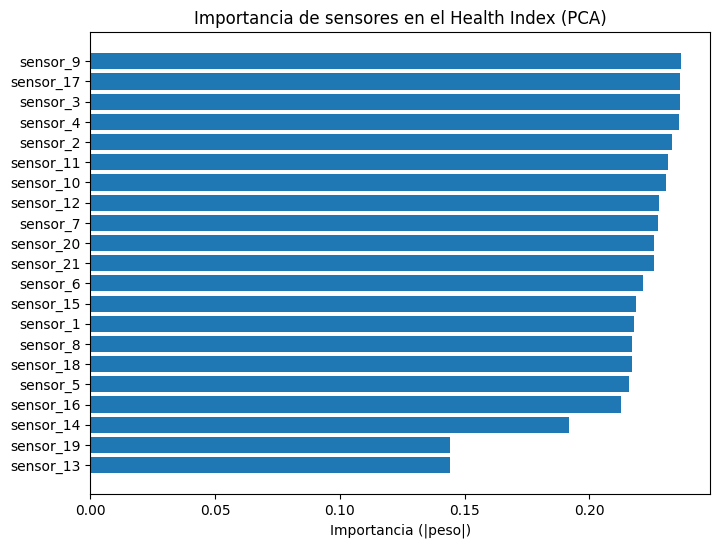

In [2299]:
# Visualización
plt.figure(figsize=(8,6))
plt.barh(
    loadings_sorted["sensor"],
    loadings_sorted["abs_weight"]
)
plt.gca().invert_yaxis()
plt.xlabel("Importancia (|peso|)")
plt.title("Importancia de sensores en el Health Index (PCA)")
plt.show()


In [2300]:
# Para mayor analisis se observa los sensores con mayor varianza en el df sin Normalizar
sensor_cols = [c for c in df.columns if "sensor" in c]

variance = df[sensor_cols].var().sort_values(ascending=False)

print(variance.head(21))

sensor_9     140368.207553
sensor_7      30322.592497
sensor_12     26959.499018
sensor_18     20309.987770
sensor_8      20285.340176
sensor_4      18577.709837
sensor_3      13965.392208
sensor_13     12358.155761
sensor_14      6500.109571
sensor_2       1804.424361
sensor_17       962.329127
sensor_1        925.400015
sensor_20       136.689346
sensor_21        49.211164
sensor_6         41.524136
sensor_19        21.680849
sensor_5         18.194955
sensor_11        11.739821
sensor_15         0.564874
sensor_10         0.020193
sensor_16         0.000025
dtype: float64


In [2301]:
#Correlación con ciclo 
corr_cycle_df = corr_cycle.reset_index() 
corr_cycle_df.columns = ["sensor", "corr_cycle"] 
#Varianza 
variance_df = variance.reset_index() 
variance_df.columns = ["sensor", "variance"] 
#Pesos PCA 
pca_df = loadings_sorted[["sensor", "abs_weight"]].copy() 
pca_df.columns = ["sensor", "pca_weight"] 
#Redundancia 
redundancy_df = redundancy_score.reset_index() 
redundancy_df.columns = ["sensor", "redundancy_score"] 

sensor_summary = ( corr_cycle_df 
    .merge(variance_df, on="sensor", how="left") 
    .merge(pca_df, on="sensor", how="left") 
    .merge(redundancy_df, on="sensor", how="left") 
)

sensor_summary_sorted = (
    sensor_summary
    .sort_values(by="pca_weight", ascending=False)
    .reset_index(drop=True)
)


sensor_summary_A = sensor_summary_sorted.copy()

sensor_summary_A = sensor_summary_A.rename(columns={
    "sensor": "sensor_A",
    "corr_cycle": "corr_cycle_A",
    "variance": "variance_A",
    "pca_weight": "pca_weight_A",
    "redundancy_score": "redundancy_score_A"
})

sensor_summary_A.to_csv("sensor_summary_A.csv", index=False)


sensor_summary_B = sensor_summary_sorted.copy()

sensor_summary_B = sensor_summary_B.rename(columns={
    "sensor": "sensor_B",
    "corr_cycle": "corr_cycle_B",
    "variance": "variance_B",
    "pca_weight": "pca_weight_B",
    "redundancy_score": "redundancy_score_B"
})

sensor_summary_B.to_csv("sensor_summary_B.csv", index=False)

sensor_summary_A


,sensor_A,corr_cycle_A,variance_A,pca_weight_A,redundancy_score_A
0,sensor_9,0.033241,140368.207553,0.236634,17
1,sensor_17,0.029852,962.329127,0.236535,17
2,sensor_3,0.029766,13965.392208,0.236511,17
3,sensor_4,0.036380,18577.709837,0.235970,15
4,sensor_2,0.012651,1804.424361,0.233349,14
5,sensor_11,0.043362,11.739821,0.231457,10
6,sensor_10,0.017375,0.020193,0.230917,15
7,sensor_12,0.013595,26959.499018,0.227761,14
8,sensor_7,0.013459,30322.592497,0.227693,14
9,sensor_20,0.010540,136.689346,0.226107,14


# DETECCIÓN EXPLORATORIA DE ANOMALÍAS USANDO HEALTH INDEX
No todas las anomalías son fallas
Algunas pueden ser:
cambios operativos
transiciones (al inicio)
ruido
inicio de degradación acelerada (cerca del final)

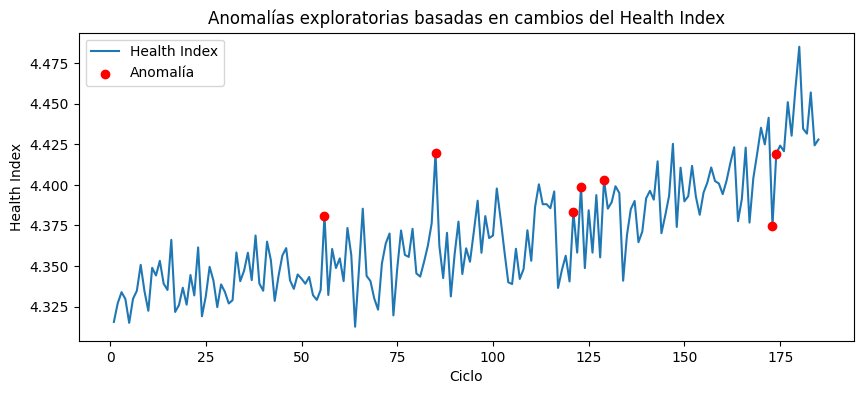

In [2302]:
# Elección del motor
engine_1 = df_eda[df_eda["engine_id"] == "FD001_99"].copy()

engine_1["hi_diff"] = engine_1["health_index"].diff()

# Se define anomalías por cambio brusco usando percentiles (Degradación Progresiva)
upper = engine_1["hi_diff"].quantile(0.969)
lower = engine_1["hi_diff"].quantile(0.005)

engine_1["anomaly"] = (
    (engine_1["hi_diff"] > upper) |
    (engine_1["hi_diff"] < lower)
)

# Visualización 
plt.figure(figsize=(10,4))

plt.plot(
    engine_1["cycle"],
    engine_1["health_index"],
    label="Health Index"
)

plt.scatter(
    engine_1.loc[engine_1["anomaly"], "cycle"],
    engine_1.loc[engine_1["anomaly"], "health_index"],
    color="red",
    label="Anomalía",
    zorder=3
)

plt.xlabel("Ciclo")
plt.ylabel("Health Index")
plt.title("Anomalías exploratorias basadas en cambios del Health Index")
plt.legend()
plt.show()


# DIVISIÓN DE MOTORES PARA TRAIN Y TEST

In [ ]:
from sklearn.model_selection import train_test_split

train_engines, test_engines = train_test_split(
    engines,
    test_size=0.2,
    random_state=42
)

train_df = df[df["engine_id"].isin(train_engines)]
test_df = df[df["engine_id"].isin(test_engines)]

print("Motores entrenamiento:", len(train_engines))
print("Motores test:", len(test_engines))

set(train_engines).intersection(set(test_engines))


Motores entrenamiento: 567
Motores test: 142


set()

# ANALISIS PARA CUANTIFICAR VENTANAS TEMPORALES:
- La ventana debe ser aproximadamente entre 10% y 15% de la media
- El análisis estadístico de la vida útil evidenció una media de 226 ciclos operativos por motor, con valores que oscilaron entre 128 y    543 ciclos. Con base en estos resultados, se definió un tamaño de ventana temporal de 30 ciclos, equivalente aproximadamente al 13% de la vida media, permitiendo capturar patrones de degradación sin perder resolución temporal.

In [ ]:

import pandas as pd

df = pd.read_csv("../data/processed/nasa_train_all_fd_clean1.csv")

life_per_engine = (
    df.groupby("engine_id")["cycle"]
    .max()
    .sort_values()
)

life_per_engine.describe()


count    709.000000
mean     226.176305
std       66.434783
min      128.000000
25%      181.000000
50%      207.000000
75%      259.000000
max      543.000000
Name: cycle, dtype: float64

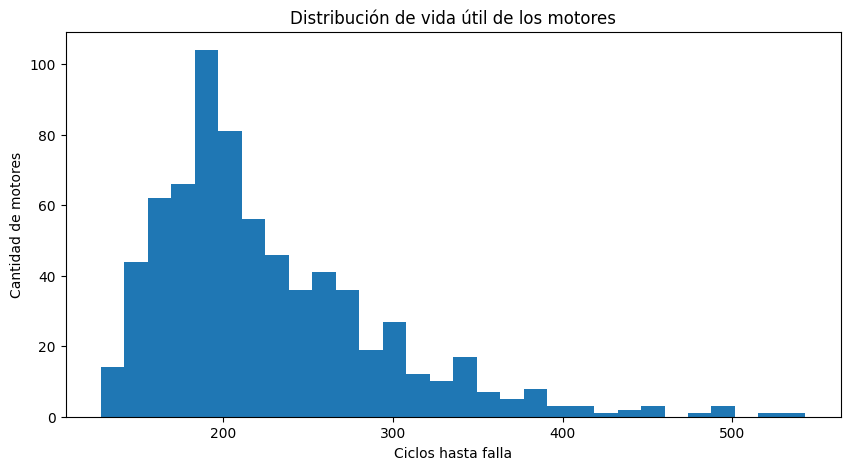

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.hist(life_per_engine, bins=30)
plt.xlabel("Ciclos hasta falla")
plt.ylabel("Cantidad de motores")
plt.title("Distribución de vida útil de los motores")
plt.show()


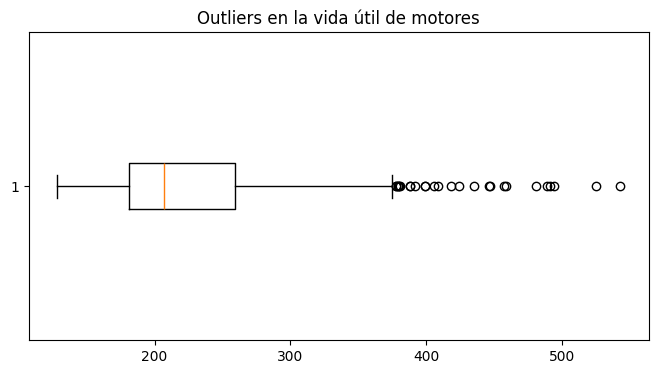

In [ ]:
plt.figure(figsize=(8,4))
plt.boxplot(life_per_engine, vert=False)
plt.title("Outliers en la vida útil de motores")
plt.show()


In [ ]:
selected_sensors = [
    "sensor_9",
    "sensor_4",
    "sensor_17",
    "sensor_11",
    "sensor_14",
    "sensor_8",
    "sensor_7",
    "sensor_21",
    "sensor_2",
    "sensor_15"
]
import json

with open("../src/learning/features.json", "w") as f:
    json.dump(selected_sensors, f)